In [25]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'
import sys

import warnings
warnings.filterwarnings("ignore")

import cv2
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)
sys.stderr = open(os.devnull, 'w')

In [26]:
import tensorflow as tf

strategy = tf.distribute.MirroredStrategy()

print("Number of GPUs:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs: 2


In [27]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import VGG16, VGG19, MobileNet, MobileNetV2

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [28]:
DATA_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset"
ANNOT_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations"
SAVE_PATH = "/kaggle/working/"

In [29]:
from collections import defaultdict  
import random
all_folders = [f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f))]

grouped = defaultdict(list)

for folder in all_folders:
    key = folder[0].upper()
    grouped[key].append(folder)

selected_folders = []

for letter in sorted(grouped.keys()):
    folders = grouped[letter]
    random.shuffle(folders)
    pick = folders[:min(2, len(folders))]
    selected_folders.extend(pick)

selected_folders = selected_folders[:50]

print("Total Selected Folders:", len(selected_folders))

Total Selected Folders: 47


In [30]:
data = []

for embryo_folder in selected_folders:

    embryo_path = os.path.join(DATA_PATH, embryo_folder)

    csv_name = embryo_folder + "_phases.csv"
    csv_path = os.path.join(ANNOT_PATH, csv_name)

    if not os.path.exists(csv_path):
        continue

    df_csv = pd.read_csv(csv_path, header=None)
    df_csv.columns = ["phase", "start", "end"]

    df_csv["start"] = df_csv["start"].astype(int)
    df_csv["end"] = df_csv["end"].astype(int)

    for img_name in os.listdir(embryo_path):

        if not img_name.endswith(".jpeg"):
            continue

        try:
            frame = int(img_name.split("RUN")[-1].split(".")[0])
        except:
            continue

        for _, row in df_csv.iterrows():
            if row["start"] <= frame <= row["end"]:
                label = row["phase"]
                img_path = os.path.join(embryo_path, img_name)
                data.append((embryo_folder, img_path, label))
                break

df = pd.DataFrame(data, columns=["folder_name", "image_path", "class_name"])

label_map = {
    "tPB2": 0,
    "tPNa": 1,
    "tPNf": 2,
    "t2": 3,
    "t3": 4,
    "t4": 5,
    "t5": 6,
    "t6": 7,
    "t7": 8,
    "t8": 9,
    "t9+": 10,
    "tM": 11,
    "tSB": 12,
    "tB": 13,
    "tEB": 14,
    "tHB": 15
}
df["label"] = df["class_name"].map(label_map)

csv_path = SAVE_PATH + "final_embryo_dataset.csv"
df.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)

Saved CSV: /kaggle/working/final_embryo_dataset.csv


In [31]:
print(sorted(df["class_name"].unique()))
print("Total classes:", df["class_name"].nunique())

['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']
Total classes: 16


In [32]:
strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [33]:
import pandas as pd
import numpy as np
import os
import cv2

from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/final_embryo_dataset.csv")

print(df.head())
print("Total samples:", len(df))
print("Classes:", df["label"].nunique())

  folder_name                                         image_path class_name  \
0    AHS599-4  /kaggle/input/datasets/abhishekbuddiga06/embry...       tPNa   
1    AHS599-4  /kaggle/input/datasets/abhishekbuddiga06/embry...         tM   
2    AHS599-4  /kaggle/input/datasets/abhishekbuddiga06/embry...        tEB   
3    AHS599-4  /kaggle/input/datasets/abhishekbuddiga06/embry...        tEB   
4    AHS599-4  /kaggle/input/datasets/abhishekbuddiga06/embry...         t8   

   label  
0      1  
1     11  
2     14  
3     14  
4      9  
Total samples: 19747
Classes: 16


In [34]:
# Extract frame number
df["frame"] = df["image_path"].apply(
    lambda x: int(x.split("RUN")[-1].split(".")[0])
)

# Sort properly
df = df.sort_values(by=["folder_name", "frame"]).reset_index(drop=True)

In [35]:
folders = df["folder_name"].unique()

train_folders, test_folders = train_test_split(
    folders, test_size=0.2, random_state=42
)

train_df = df[df["folder_name"].isin(train_folders)]
test_df  = df[df["folder_name"].isin(test_folders)]

print("Train embryos:", len(train_folders))
print("Test embryos:", len(test_folders))

Train embryos: 37
Test embryos: 10


In [36]:
# def sequence_generator(dataframe, seq_len=5, batch_size=16):

#     while True:
#         batch_x, batch_y = [], []

#         for folder in dataframe["folder_name"].unique():

#             df_f = dataframe[dataframe["folder_name"] == folder]

#             for i in range(len(df_f) - seq_len):

#                 seq_imgs = []
                
#                 for j in range(seq_len):
#                     img_path = df_f.iloc[i+j]["image_path"]
#                     img = cv2.imread(img_path)

#                     if img is None:
#                         continue

#                     img = cv2.resize(img, (128,128)) / 255.0
#                     seq_imgs.append(img)

#                 if len(seq_imgs) == seq_len:
#                     label = df_f.iloc[i+seq_len-1]["label"]

#                     batch_x.append(seq_imgs)
#                     batch_y.append(label)

#                 if len(batch_x) == batch_size:
#                     yield np.array(batch_x), tf.keras.utils.to_categorical(batch_y, 15)
#                     batch_x, batch_y = [], []


def sequence_generator(dataframe, seq_len=5, batch_size=16):

    while True:
        batch_x, batch_y = [], []

        folders = np.random.permutation(dataframe["folder_name"].unique())

        for folder in folders:

            df_f = dataframe[dataframe["folder_name"] == folder].sort_values("frame")

            for i in range(len(df_f) - seq_len):

                seq_imgs = []

                for j in range(seq_len):
                    img_path = df_f.iloc[i+j]["image_path"]
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    img = cv2.resize(img, (128,128)) / 255.0
                    seq_imgs.append(img)

                if len(seq_imgs) == seq_len:
                    label = df_f.iloc[i+seq_len-1]["label"]

                    batch_x.append(seq_imgs)
                    batch_y.append(label)

                if len(batch_x) == batch_size:
                    yield np.array(batch_x), tf.keras.utils.to_categorical(batch_y, NUM_CLASSES)
                    batch_x, batch_y = [], []

In [37]:
SEQ_LEN = 5
NUM_CLASSES = df["label"].nunique()

base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

def build_lstm_model():

    inputs = Input(shape=(SEQ_LEN, 128,128,3))

    x = TimeDistributed(base_model)(inputs)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(128)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

In [46]:
from tensorflow.keras.optimizers import Adam

# strategy = tf.distribute.MirroredStrategy()

# with strategy.scope():
model = build_lstm_model()
model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 5, 128, 128, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 4, 4, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,988,688 (11.40 MB)

 Trainable params: 730,704 (2.79 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [47]:
train_gen = sequence_generator(train_df, seq_len=SEQ_LEN, batch_size=16)
test_gen  = sequence_generator(test_df,  seq_len=SEQ_LEN, batch_size=16)

In [48]:
NUM_CLASSES = df["label"].nunique()
print(NUM_CLASSES)  # should be 16

16


In [49]:
expected_classes = [
    "tPB2","tPNa","tPNf","t2","t3","t4","t5","t6",
    "t7","t8","t9+","tM","tSB","tB","tEB","tHB"
]

print("Present:", sorted(df["class_name"].unique()))

missing = set(expected_classes) - set(df["class_name"].unique())
print("Missing classes:", missing)

Present: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']
Missing classes: set()


In [50]:
print("Model output:", model.output_shape)

Model output: (None, 16)


In [51]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping


In [52]:
best_ckpt = ModelCheckpoint(
    "/kaggle/working/lstm_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

backup_ckpt = ModelCheckpoint(
    "/kaggle/working/lstm_backup.keras",
    save_best_only=False,
    verbose=1
)

csv_logger = CSVLogger(
    "/kaggle/working/lstm_log.csv",
    append=True
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df)//16,
    validation_data=test_gen,
    validation_steps=len(test_df)//16,
    epochs=30,
    callbacks=[best_ckpt, backup_ckpt, csv_logger, early_stop]
)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.2495 - loss: 2.5106
Epoch 1: val_accuracy improved from -inf to 0.34623, saving model to /kaggle/working/lstm_best.keras

Epoch 1: saving model to /kaggle/working/lstm_backup.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 425s 415ms/step - accuracy: 0.2495 - loss: 2.5105 - val_accuracy: 0.3462 - val_loss: 2.0832
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.3608 - loss: 2.0134
Epoch 2: val_accuracy improved from 0.34623 to 0.35342, saving model to /kaggle/working/lstm_best.keras

Epoch 2: saving model to /kaggle/working/lstm_backup.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 269s 275ms/step - accuracy: 0.3608 - loss: 2.0134 - val_accuracy: 0.3534 - val_loss: 1.9080
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.4533 - loss: 1.7287
Epoch 3: val_accuracy improved from 0.35342 to 0.39162, saving model to /kaggle/working/lstm_best.keras

Epoch 3: saving model to /kaggle/working/lstm_backup.keras
981/9

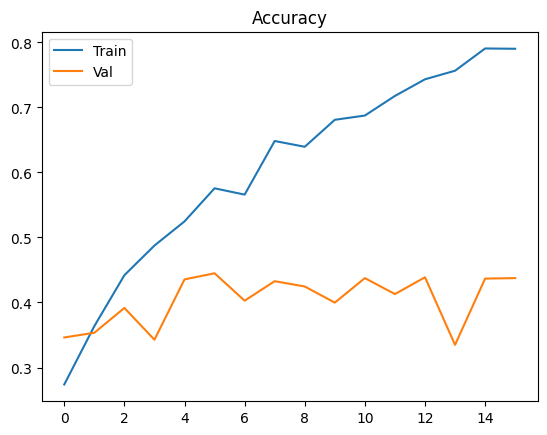

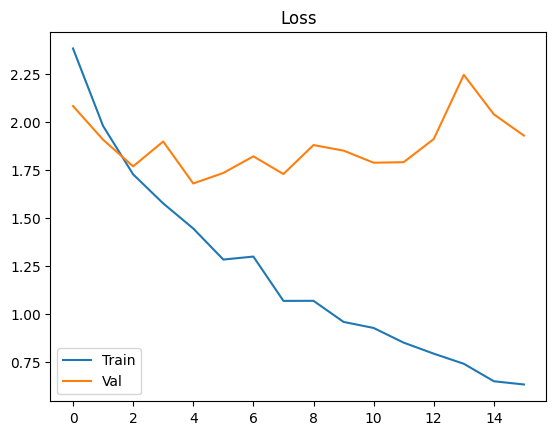

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.legend()
plt.title("Accuracy")  
plt.show()
                   
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.legend()
plt.title("Loss")
plt.show()

In [54]:
# Final Training Accuracy & Loss
train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]

# Final Validation Accuracy & Loss
val_acc = history.history['val_accuracy'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Training Loss:", train_loss)

print("Final Validation Accuracy:", val_acc)
print("Final Validation Loss:", val_loss)

Final Training Accuracy: 0.7902650237083435
Final Training Loss: 0.6334142684936523
Final Validation Accuracy: 0.4375
Final Validation Loss: 1.929261565208435


In [55]:
test_loss, test_acc = model.evaluate(
    test_gen,
    steps=len(test_df)//32
)

print("Final Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

126/126 ━━━━━━━━━━━━━━━━━━━━ 28s 224ms/step - accuracy: 0.4419 - loss: 1.7525
Final Test Accuracy: 0.4697420597076416
Final Test Loss: 1.587348461151123
